In [21]:
import pandas as pd
from sklearn.model_selection import GroupKFold
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
cohort = "brca"

data_path = '../../data/clinical_data'
filename = f'{cohort}_clinical'
n_folds = 5

In [5]:
df = pd.read_csv(f"{data_path}/{filename}.csv", index_col=0)
df['location'] = df['case_id'].apply(lambda x: x.split('-')[1])
df.head()

,case_id,dss_survival_days,dss_censorship,location
0,TCGA-3C-AAAU,4047.0,1,3C
1,TCGA-3C-AALI,4005.0,1,3C
2,TCGA-3C-AALJ,1474.0,1,3C
3,TCGA-3C-AALK,1448.0,1,3C
4,TCGA-4H-AAAK,348.0,1,4H


In [ ]:
summary_df = (
    df.groupby("location")
    .agg(
        n_samples=("case_id", "count"),
        mean_survival=("dss_survival_days", "mean"),
        std_survival=("dss_survival_days", "std")
    )
    .reset_index()
    .sort_values("n_samples", ascending=False)
)

summary_df[["mean_survival", "std_survival"]] = summary_df[
    ["mean_survival", "std_survival"]
].round(2)

summary_df

,location,n_samples,mean_survival,std_survival
14,BH,140,1345.67,874.75
5,A2,102,1539.99,1026.86
17,E2,90,1187.46,659.03
7,A8,83,632.04,551.54
16,D8,78,590.82,318.32
12,AR,64,2555.94,1043.46
18,E9,62,837.68,427.04
13,B6,56,3531.52,2354.76
15,C8,49,397.49,234.22
8,AC,48,838.23,787.30


In [8]:
summary_df["sem"] = summary_df["std_survival"] / summary_df["n_samples"]**0.5
summary_df["cv"] = summary_df["std_survival"] / summary_df["mean_survival"]
summary_df["survival_bin"] = pd.cut(
    summary_df["mean_survival"],
    bins=[0, 500, 1000, 2000, 4000, 10000],
    labels=["very_low", "low", "mid", "high", "very_high"]
)

In [9]:
summary_df

,location,n_samples,mean_survival,std_survival,sem,cv,survival_bin
14,BH,140,1345.67,874.75,73.929868,0.650048,mid
5,A2,102,1539.99,1026.86,101.674291,0.666797,mid
17,E2,90,1187.46,659.03,69.467862,0.554991,mid
7,A8,83,632.04,551.54,60.539380,0.872635,low
16,D8,78,590.82,318.32,36.042643,0.538777,low
12,AR,64,2555.94,1043.46,130.432500,0.408249,high
18,E9,62,837.68,427.04,54.234134,0.509789,low
13,B6,56,3531.52,2354.76,314.668041,0.666784,high
15,C8,49,397.49,234.22,33.460000,0.589248,very_low
8,AC,48,838.23,787.30,113.636967,0.939241,low


<Figure size 2200x800 with 0 Axes>

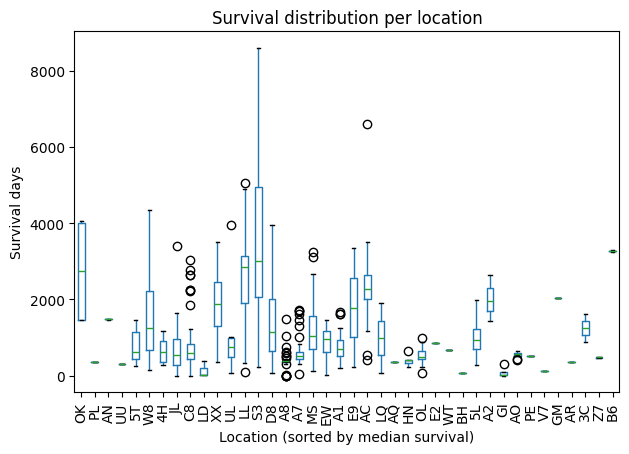

In [14]:
order = (
    df.groupby("location")["dss_survival_days"]
    .mean()
    .sort_values()
    .index
)

plt.figure(figsize=(22, 8))

df.boxplot(
    column="dss_survival_days",
    by="location",
    rot=90,
    grid=False,
    # showfliers=False,  # 🔥 usuwa outliery (czytelność!)
    positions=range(len(order)),
    return_type=None
)

plt.title("Survival distribution per location")
plt.suptitle("")  # usuwa domyślny pandas title
plt.xlabel("Location (sorted by median survival)")
plt.ylabel("Survival days")

# 🔥 ręczne ustawienie etykiet w kolejności
plt.xticks(range(len(order)), order)

plt.tight_layout()
plt.show()

In [16]:
base_path = "../../data/clinical_data/brca_clinical/splits"  # <- PODMIEŃ

folds = range(5)
data = []

for f in folds:
    test_path = os.path.join(base_path, str(f), "test_filtered.csv")
    
    df_test = pd.read_csv(test_path)
    df_test["fold"] = f
    df_test["set"] = "test"
    
    data.append(df_test)

df_all = pd.concat(data, ignore_index=True)

In [25]:
location_survival = (
    df_all.groupby(["fold"])
    .agg(
        mean_survival=("dss_survival_days", "mean"),
        std_survival=("dss_survival_days", "std"),
        n=("case_id", "count"),
        n_locations=("location", "nunique")  # 🔥 NOWE
    )
    .reset_index()
)
print(location_survival)

   fold  mean_survival  std_survival    n  n_locations
0     0    1196.254630    839.989000  216            7
1     1     935.604651    988.961207  215            9
2     2    1759.502347   1720.829626  213            7
3     3     741.823256    565.132659  215            8
4     4    1483.079070   1138.768013  215            9


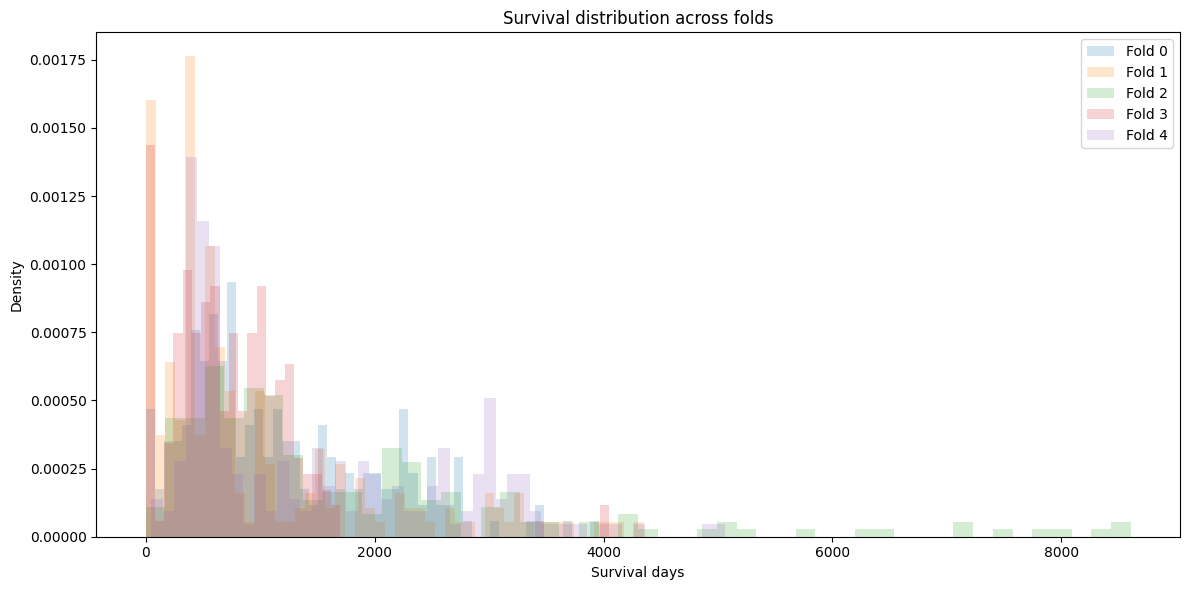

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bins = 50  # możesz zmienić

for fold in sorted(df_all["fold"].unique()):
    subset = df_all[df_all["fold"] == fold]
    
    plt.hist(
        subset["dss_survival_days"],
        bins=bins,
        alpha=0.2,          # 🔥 przezroczystość
        label=f"Fold {fold}",
        density=True        # 🔥 porównywalne rozkłady
    )

plt.xlabel("Survival days")
plt.ylabel("Density")
plt.title("Survival distribution across folds")
plt.legend()
plt.tight_layout()
plt.show()

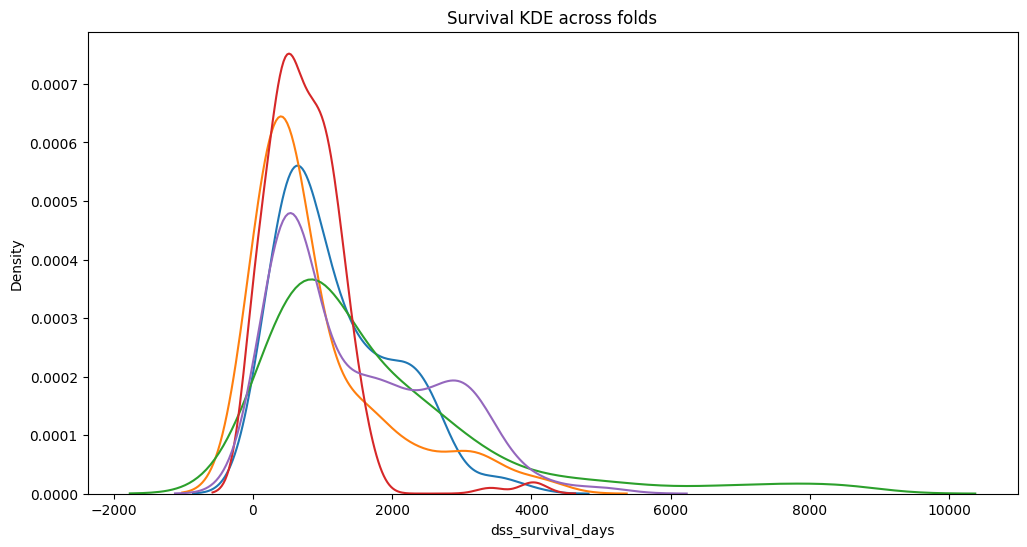

In [ ]:
plt.figure(figsize=(12, 6))

for fold in sorted(df_all["fold"].unique()):
    sns.kdeplot(
        df_all[df_all["fold"] == fold]["dss_survival_days"],
        label=f"Fold {fold}",
        fill=False
    )

plt.title("Survival KDE across folds")
plt.show()

<Figure size 1000x600 with 0 Axes>

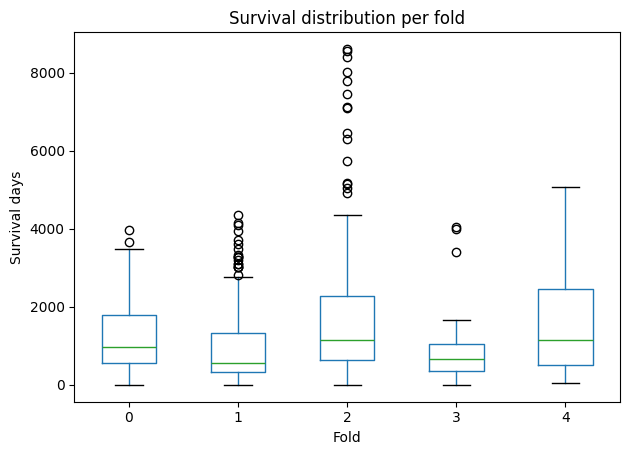

In [31]:
plt.figure(figsize=(10, 6))

df_all.boxplot(
    column="dss_survival_days",
    by="fold",
    grid=False,
    # showfliers=False  # 🔥 czytelniej (bez outlierów)
)

plt.title("Survival distribution per fold")
plt.suptitle("")  # usuwa domyślny pandas title
plt.xlabel("Fold")
plt.ylabel("Survival days")

plt.tight_layout()
plt.show()

In [32]:
(df_all["dss_survival_days"] < 0).sum()

0

In [35]:
df_all[df_all["dss_censorship"] == 0]

,case_id,dss_survival_days,dss_censorship,location,fold,set
6,TCGA-AC-A23H,174.0,0,AC,0,test
11,TCGA-AC-A2FE,2636.0,0,AC,0,test
15,TCGA-AC-A2FM,792.0,0,AC,0,test
19,TCGA-AC-A2QJ,446.0,0,AC,0,test
38,TCGA-AC-A62V,348.0,0,AC,0,test
...,...,...,...,...,...,...
984,TCGA-AR-A5QQ,322.0,0,AR,4,test
1021,TCGA-D8-A1XC,377.0,0,D8,4,test
1040,TCGA-D8-A1Y1,302.0,0,D8,4,test
1061,TCGA-D8-A73W,385.0,0,D8,4,test
